# Plate artifacts and corrections

Plates drift, well position matters, and cell count affects most features. This page shows how to see those
artifacts, removes them, and measures whether removing them helped.

Every correction here can make results worse on a given dataset. The last section shows a real case where
sphering, a standard step of the pipeline, cuts mechanism retrieval by seventy percent.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc

import mantispy as mt
from mantispy._core.plate import well_row

## Position effects

Edge wells evaporate, corners sit at a different temperature, and dispensing drifts along a
row. `correct_plate_position` fits Tukey's median polish to the row and column effects of
each plate and subtracts them. Median polish is used instead of a mean-based fit so that a few
extreme wells do not define the gradient.

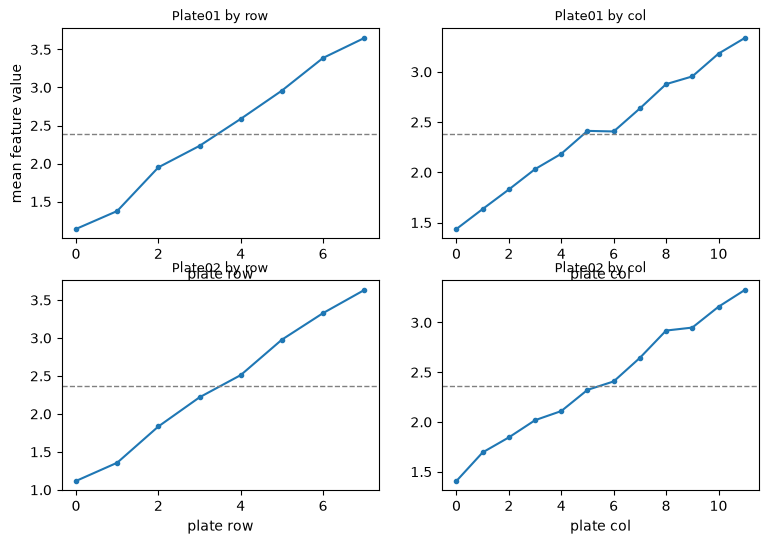

In [2]:
cells = mt.ds.synthetic_plate(
    n_plates=2,
    n_wells=96,
    n_cells=20,
    n_features=30,
    row_gradient=3.0,
    col_gradient=2.0,
    seed=0,
)
wells = mt.tl.aggregate(cells)
mt.pl.plate_effects(wells)
plt.show()

`pl.plate_effects` shows row and column marginals per plate. A position artifact appears as a trend across
rows or columns, while noise scatters around the plate median.

In [3]:
rows = np.array([well_row(w) for w in wells.obs["Metadata_Well"]])
before = abs(np.corrcoef(rows, wells.X[:, 0])[0, 1])

mt.pp.correct_plate_position(wells)
after = abs(np.corrcoef(rows, wells.X[:, 0])[0, 1])
{"correlation with plate row, before": round(float(before), 3), "after": round(float(after), 3)}

{'correlation with plate row, before': 0.744, 'after': 0.016}

If treatments are laid out by column, fit the effects on the controls only, with
`reference="negcon"`, so that treatment effects are not absorbed into a column effect and
subtracted.

This has a limit. A median polish can only fit a column effect for columns that contain
reference rows, and most layouts put the controls in a few fixed columns, such as 1 and 2 or
23 and 24. With controls in four of twenty-four columns there is no control-only column effect
to fit. Row effects still work, because controls in an edge column span every row. For column
effects on a column-wise layout, the design has confounded the effect you want to correct, and
the fix is a randomized layout on the next plate.

## Confounders

Cell count is the most common one: a sparse well looks different from a confluent one
regardless of treatment. `regress_out` fits each feature against the confounder within each
plate and keeps the residual.

In [4]:
confounded = mt.ds.synthetic_plate(n_wells=96, n_cells=30, n_features=20, confounder_effect=3.0, seed=0)
profiles = mt.tl.aggregate(confounded, min_cells=0)
feature = profiles.uns["mantispy"]["truth"]["confounded_features"][0]
position = profiles.var_names.get_loc(feature)
counts = profiles.obs["Metadata_CellCount"].to_numpy(dtype=float)

before = abs(np.corrcoef(counts, profiles.X[:, position])[0, 1])
mt.pp.regress_out(profiles, keys=("Metadata_CellCount",), by=None)
after = abs(np.corrcoef(counts, profiles.X[:, position])[0, 1])
{"correlation with cell count, before": round(float(before), 3), "after": round(float(after), 3)}

{'correlation with cell count, before': 0.985, 'after': 0.0}

Missing values stay missing. Imputing them for the regression and writing the fitted value
back would make an unmeasured value look like a real measurement.

## Sphering

Sphering is typical variation normalization. The covariance of the negative controls
describes variation that is not of interest, and whitening removes it, leaving the variation
caused by the perturbations.

`ZCA-cor` is the default because it rotates back into the original feature basis, so the
columns still match `var`. `PCA` and `PCA-cor` return principal components instead and warn
when they overwrite `X`, because `var` then no longer describes the columns.

Sphering needs more control wells than features. With fewer, the control covariance is
singular, the null directions are padded, and the transform amplifies noise. `sphere` warns
when that happens, and the last section shows the cost.

## Batches

A batch effect moves the controls too. `pl.control_drift` projects the control wells onto components
fitted on the controls alone, so if the controls of different batches land in different places, the
reference itself shifts between them.

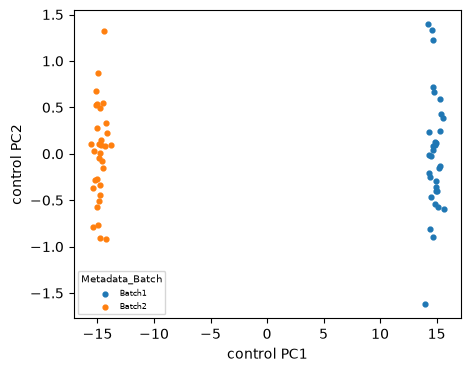

In [5]:
batched = mt.ds.synthetic_plate(
    n_plates=4,
    n_wells=96,
    n_cells=10,
    n_features=30,
    n_batches=2,
    batch_effect=4.0,
    n_perturbations=5,
    effect_size=3.0,
    seed=0,
)
batched = mt.tl.aggregate(batched, min_cells=0)
mt.pl.control_drift(batched, groupby="Metadata_Batch")
plt.show()

### Measuring the result

`mt.metrics` scores a representation with several metrics. Batch-mixing metrics and
biological-signal metrics trade off against each other, and a correction that improves one
at the expense of the other has not helped.

In [6]:
sc.pp.pca(batched, n_comps=15)

corrected = batched.copy()
mt.pp.normalize(corrected, method="standardize", by="Metadata_Batch")
sc.pp.pca(corrected, n_comps=15)
batched.obsm["X_batch_centred"] = corrected.obsm["X_pca"]

table = mt.metrics.evaluate_correction(
    batched,
    reps=("X_pca", "X_batch_centred"),
    label_key="Metadata_Perturbation",
    batch_key="Metadata_Batch",
)
table

,metric,representation,key,value,better
0,silhouette_label,X_pca,Metadata_Perturbation,5.682465e-01,higher
1,silhouette_batch,X_pca,Metadata_Batch,7.278925e-02,higher
2,ilisi,X_pca,Metadata_Batch,1.000000e+00,higher
3,clisi,X_pca,Metadata_Perturbation,1.009925e+00,lower
4,pc_regression,X_pca,Metadata_Batch,8.735887e-01,lower
5,silhouette_label,X_batch_centred,Metadata_Perturbation,6.665337e-01,higher
6,silhouette_batch,X_batch_centred,Metadata_Batch,9.599711e-01,higher
7,ilisi,X_batch_centred,Metadata_Batch,1.953133e+00,higher
8,clisi,X_batch_centred,Metadata_Perturbation,1.026559e+00,lower
9,pc_regression,X_batch_centred,Metadata_Batch,1.104450e-14,lower


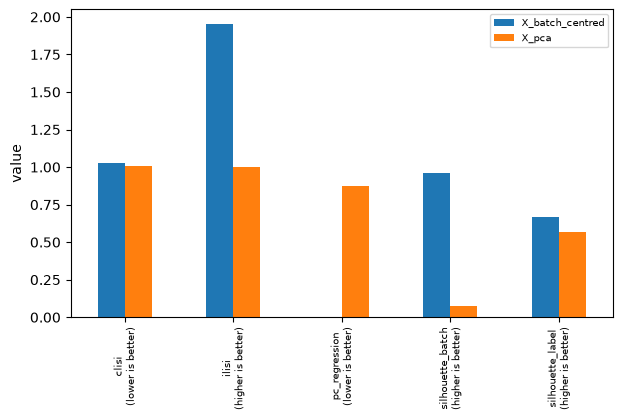

In [7]:
mt.pl.metrics(table)
plt.show()

Check the `better` column: two of the five metrics are better when lower. `pc_regression` is
the share of variance explained by batch, so centering each batch should lower it, and it
does.

`pl.batch_variance` shows the same per component, which tells you where in the embedding the
batch effect sits.

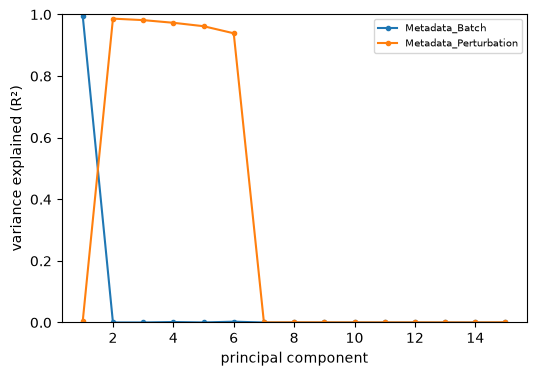

In [8]:
mt.pl.batch_variance(batched, keys=["Metadata_Batch", "Metadata_Perturbation"], use_rep="X_pca")
plt.show()

Harmony, the last step of the JUMP recipe, corrects an embedding rather than the features.
[Reproducing across laboratories](../multisite/cross_laboratory.ipynb) runs it on JUMP and measures the result.
For a correction on the features instead of an embedding, `sc.pp.combat` is the usual choice.

## A correction that makes things worse

Sphering is a standard step of the Broad recipe, but it needs more control wells than features. BBBC021 {cite:p}`Ljosa_2013`
has few control wells for the features that survive selection, so its control covariance is singular. Score
mechanism retrieval with and without sphering, with the not-same-compound rule from
[Mechanism of action](../compounds/mechanism_of_action.ipynb).

In [9]:
def not_same_compound(adata):
    """Not-same-compound mechanism retrieval on one signature per treatment."""
    treated = adata[~adata.obs["Metadata_Control"].to_numpy()].copy()
    signatures = mt.tl.consensus(treated, method="median", min_replicates=1)
    signatures = signatures[signatures.obs["Metadata_MOA"].notna().to_numpy()].copy()
    mt.tl.nn_moa_classify(signatures, scheme="nsc")
    return round(signatures.uns["mantispy"]["moa"]["accuracy"], 3)


bbbc = mt.ds.bbbc021()
mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")
mt.pp.feature_select(bbbc, na_cutoff=0.0)
bbbc = mt.pp.subset_features(bbbc)

sphered = bbbc.copy()
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    mt.pp.sphere(sphered, method="ZCA-cor", reference="negcon")
print(caught[0].message)

{
    "control wells": int(bbbc.obs["Metadata_Control"].sum()),
    "features": bbbc.n_vars,
    "without sphering": not_same_compound(bbbc),
    "with sphering": not_same_compound(sphered),
}

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/var/folders/qg/qgc908995g3fc8qtss2fsbhhxyxxj4/T/ipykernel_99188/1216217037.py:11: UserWarning: 2 of 473 features have no spread in at least one group of 'Metadata_Plate' among the rows selected by reference='negcon'. Adding epsilon=1e-18 to their scale multiplies them by up to 1e18, so they dominate every distance downstream. They are flagged in var['degenerate_scale'], and pp.feature_select drops them by default; to drop them now, adata = adata[:, ~adata.var['degenerate_scale']].copy(). A variance or outlier cut does not catch a feature that varies across a plate but is constant among its control wells; the flag does.
  mt.pp.normalize(bbbc, method="mad_robustize", by="Metadata_Plate", reference="negcon")


sphering is fitted on 330 reference rows for 344 features. With fewer rows than features the covariance is singular and the transform amplifies noise (on BBBC021 it lowered not-same-compound MOA retrieval from 78% to 22%). Select fewer features first, or use more controls.


{'control wells': 330,
 'features': 344,
 'without sphering': 0.777,
 'with sphering': 0.223}

Sphering cuts not-same-compound accuracy from 0.78 to 0.22, a loss of seventy percent, on 330 control wells for
344 features. mantispy's sphering is tested against pycytominer's, so pycytominer should show the same drop.

Measure a correction on the question the screen asks before adopting it. For this dataset, either select fewer
features so the control covariance is well determined, or skip sphering.

Next: [Is the screen any good?](screen_quality.ipynb)